#**Inteligência Artificial**

## **Autor**

Professor: **Cristóvão José Dias da Cunha**

E-mail: **cristovao.cunha@gmail.com**

Site: [https://www.feg.unesp.br/cristovao](https://www.feg.unesp.br/cristovao)

Youtube: [https://www.youtube.com/channel/UCTwTFh0fSihjozAQ6qkL40Q](https://www.youtube.com/channel/UCTwTFh0fSihjozAQ6qkL40Q)

## **Sobre**

Serão estudadas:


*   Entendendo as bibliotecas utilizadas
*   Conectando ao Google Drive pelo Colab
*   Carregar os dados de um arquivo CSV
*   Limpar os dados, revovendo as linhas duplicadas
*   Separar os dados em treino e teste
*   Remover as colunas não utilizadas
*   Tratar valores vazios
*   Transformar colunas categóricas em numéricas
*   Separar a variável target das features
*   Treinar modelos de aprendizado de máquina supervisionados de classificação
*   Analisar qual o melhor modelo
    *    Acurácia
    *    Matriz de confusão
    *    Curva ROC e AUC






# **Dataset da Flor de Íris**

<img src="http://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png" width="700" height="200"/>

## **Bibliotecas**

Nesta análise usaremos 4 bibliotecas famosas do Python. São elas:

[**Pandas**](https://pandas.pydata.org): é uma biblioteca para manipulação e análise de dados. Em particular, oferece estruturas e operações para manipular tabelas numéricas e séries temporais.

[**Numpy**](https://numpy.org): é uma biblioteca que suporta arrays e matrizes multidimensionais, possuindo uma larga coleção de funções matemáticas para trabalhar com estas estruturas.

[**Matplotlib**](https://matplotlib.org): é uma biblioteca para criação de gráficos e visualizações de dados em geral, é a extensão do NumPy.

[**Scikit-learn**](https://scikit-learn.org): é uma biblioteca de aprendizado de máquina de código aberto, que inclui vários algoritmos de classificação, regressão e agrupamento.

Importando as bibliotecas necessárias para a análise desse dataset:

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import plot_roc_curve

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

## **Conectando seu Google Drive ao Colab**

Para conectar seu Google Drive ao Colab, utilize as linhas abaixo. Será apresentado um link, que após sua autenticação e liberação irá gerar uma chave de acesso, que deve ser copiada e colada aqui no seu notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Lendo um arquivo CSV**

Como já visto em exemplos anteriores, podemos ler um arquivo CSV, que é carregado no Colab:

```
df = pd.read_csv('caminho/arquivo.csv')
```


In [ ]:
arquivo = '/content/drive/MyDrive/Colab Notebooks/CSV/iris.csv'
df = pd.read_csv(arquivo)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Mas, também, podemos ler um arquivo diretamente de um endereço na web:


```
df = pd.read_csv('https://www.site.com.br/arquivo.csv')
```



In [ ]:
df = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
df

In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


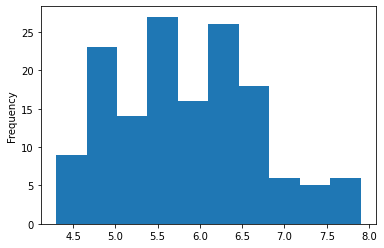

In [ ]:
#df.sepal_length.plot.hist(bins=10)
df['sepal_length'].plot.hist(bins=10)

## **Removendo linhas duplicadas**

In [ ]:
df['species']

In [ ]:
df.species

In [ ]:
type(df['species'])

In [ ]:
df['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

**`pandas.DataFrame.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)`**

Retorna um `DataFrame` com as linhas duplicadas removidas.

A consideração de certas colunas é opcional, sou seja, não é obrigatório especificar a coluna desejada, pode ser executado sobre todo `DataFrame`. Índices, incluindo os de hora/tempo são ignorados.

**Parameters:**

> `subset` : rótulo das colunas ou sequência de rótulos, opcional.

Considera apenas certas colunas para identificar duplicatas; por padrão, usa todas as colunas.

> `keep` : {‘first’, ‘last’, False}, padrão ‘first’

Determina quais duplicatas (se houver), deve manter. 

*   `first` : Elimina as duplicatas, exceto para a primeira ocorrência. 
*   `last` : Elimina as duplicatas, exceto para a última ocorrência. 
*   `False` : Elimina todas as duplicatas.

> `inplace` : bool, padrão False

Se deseja remover as duplicatas no local ou retornar uma cópia. 

> `ignore_index` : bool, padrão False

Se `True`, o eixo (*axis*) resultante será rotulado por 0, 1, ..., n - 1.


**Returns:**

> `DataFrame` or `None`

`DataFrame` com as duplicatas removidas ou `None` se `inplace=True`.



In [ ]:
df['species'].drop_duplicates()

0          setosa
50     versicolor
100     virginica
Name: species, dtype: object

In [ ]:
df['species'].drop_duplicates(keep='last')

## Separar em Treino e Teste

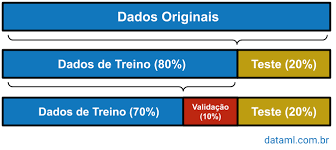

In [ ]:
train , test = train_test_split(df, test_size = 0.2, random_state = 1)

In [ ]:
train.head()

,sepal_length,sepal_width,petal_length,petal_width,species
91,6.1,3.0,4.6,1.4,versicolor
135,7.7,3.0,6.1,2.3,virginica
69,5.6,2.5,3.9,1.1,versicolor
128,6.4,2.8,5.6,2.1,virginica
114,5.8,2.8,5.1,2.4,virginica


In [ ]:
test.head()

,sepal_length,sepal_width,petal_length,petal_width,species
14,5.8,4.0,1.2,0.2,setosa
98,5.1,2.5,3.0,1.1,versicolor
75,6.6,3.0,4.4,1.4,versicolor
16,5.4,3.9,1.3,0.4,setosa
131,7.9,3.8,6.4,2.0,virginica


## Retirar colunas que não usaremos

<img src="https://cdn2.iconfinder.com/data/icons/flat-pro-word-processing-set-5/32/table-column-delete-512.png" width="200" height="100"/>

### Podemos usar a coluna **species**?

**NÃO!!!**

### Pq?

**Pq ela é categórica/object!**

### Podemos retirar/remover a coluna **species**?

**Ainda, não!**

## Valor Vazio

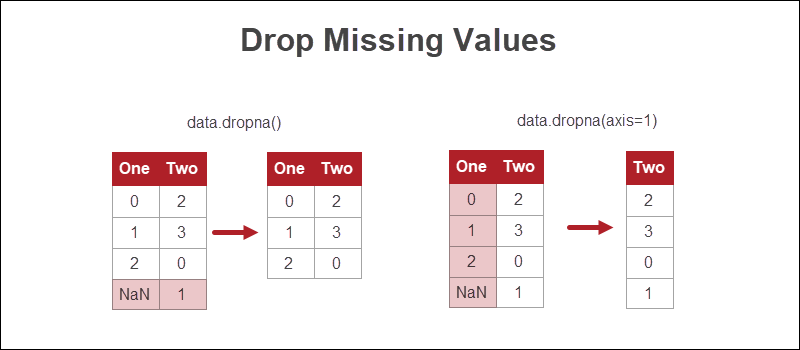

In [ ]:
pd.isna(df)

In [ ]:
pd.isna(df).sum()

In [ ]:
pd.isna(df).sum().to_frame('Valor Vazio')

,Valor Vazio
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


## Categóricas em numéricas

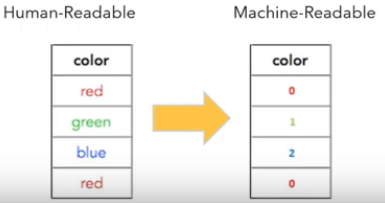

<img src="https://miro.medium.com/max/1879/1*O_pTwOZZLYZabRjw3Ga21A.png" width="600" height="200"/>

In [ ]:
train[ train['species'] == 'setosa' ]

In [ ]:
train[train['species'] == 'setosa'] ['sepal_length']

In [ ]:
train[train['species'] == 'setosa'] [ ['sepal_length'] ]

In [ ]:
train[train['species'] == 'setosa'] [ ['sepal_length', 'sepal_width'] ]

In [ ]:
type(df)

In [ ]:
type(train)

In [ ]:
# df         condicao de filtragem                campos 
train [ train['species'] == 'setosa' ] [ ['sepal_length','petal_length'] ]

# select 'sepal_length','petal_length' from train where species == 'setosa';

In [ ]:
train = train.query("species == 'versicolor' | species == 'virginica'")
test = test.query("species == 'versicolor' | species == 'virginica'")

In [ ]:
train['species'].value_counts()

virginica     44
versicolor    37
Name: species, dtype: int64

In [ ]:
train.head()

In [ ]:
train['species'] = np.where(train['species'] == 'versicolor', 0, 1)
test['species']  = np.where(test['species'] == 'versicolor', 0, 1)

In [ ]:
train

,sepal_length,sepal_width,petal_length,petal_width,species
91,6.1,3.0,4.6,1.4,0
135,7.7,3.0,6.1,2.3,1
69,5.6,2.5,3.9,1.1,0
128,6.4,2.8,5.6,2.1,1
114,5.8,2.8,5.1,2.4,1
...,...,...,...,...,...
79,5.7,2.6,3.5,1.0,0
133,6.3,2.8,5.1,1.5,1
137,6.4,3.1,5.5,1.8,1
72,6.3,2.5,4.9,1.5,0


In [ ]:
df.info()

## Separar a variável target das features (tanto do treino como do teste)
<img src="https://i.ibb.co/3csjYT2/image.png" width="400" height="200"/>

**Nota importante**:

axis = 0 -> Linhas

axis = 1 -> Colunas

In [ ]:
train.head()

In [ ]:
train_x = train.drop('species', axis = 1)
train_y = train['species']

In [ ]:
test_x = test.drop('species', axis = 1)
test_y = test['species']

In [ ]:
train_x.head()

,sepal_length,sepal_width,petal_length,petal_width
91,6.1,3.0,4.6,1.4
135,7.7,3.0,6.1,2.3
69,5.6,2.5,3.9,1.1
128,6.4,2.8,5.6,2.1
114,5.8,2.8,5.1,2.4


In [ ]:
train_y.head()

91     0
135    1
69     0
128    1
114    1
Name: species, dtype: int64

## **Variável target, alvo ou categórica**

## Treinar o modelo com os principais algorítimos supervisionados de Classificação
<img src="https://i.ibb.co/N3pbLFp/LR-LDA-DT-KNN-SVM-RF.png" width="200" height="160"/>

Treinar = Fit

In [ ]:
LiR = LinearRegression().fit(train_x, train_y)

LR  = LogisticRegression(solver = 'lbfgs', max_iter = 1000).fit(train_x, train_y)
LDA = LinearDiscriminantAnalysis().fit(train_x, train_y)
DT  = DecisionTreeClassifier().fit(train_x, train_y)
KNN = KNeighborsClassifier().fit(train_x, train_y)
SVM = SVC().fit(train_x,train_y) 
RF  = RandomForestClassifier().fit(train_x,train_y)

## Verificando qual o melhor modelo

In [ ]:
print("Acurácia LiR:", LiR.score(test_x, test_y), "\n")

print("Acurácia LR:",  LR. score(test_x, test_y), "\n")
print("Acurácia LDA:", LDA.score(test_x, test_y), "\n")
print("Acurácia DT:",  DT. score(test_x, test_y), "\n")
print("Acurácia KNN:", KNN.score(test_x, test_y), "\n")
print("Acurácia SVM:", SVM.score(test_x, test_y), "\n")
print("Acurácia RF:",  SVM.score(test_x, test_y), "\n")

Acurácia LiR: 0.6927992485540877 

Acurácia LR: 0.9473684210526315 

Acurácia LDA: 1.0 

Acurácia DT: 0.9473684210526315 

Acurácia KNN: 1.0 

Acurácia SVM: 0.9473684210526315 

Acurácia RF: 0.9473684210526315 



## Matriz de confusão + Métricas
<img src="https://www.researchgate.net/profile/Rune-Jacobsen/publication/334840641/figure/fig3/AS:794222751928321@1566368868347/Confusion-matrix-and-evaluation-metrics.png" width="600" height="300"/>

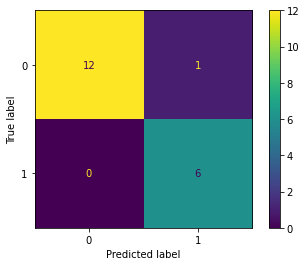

In [ ]:
#ConfusionMatrixDisplay
plot_confusion_matrix(LR, test_x, test_y)
plt.show();

## Curva ROC
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Roc-draft-xkcd-style.svg/250px-Roc-draft-xkcd-style.svg.png" width="600" height="300"/>

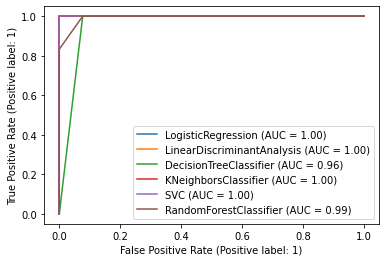

In [ ]:
#RocCurveDisplay
plot_roc_curve(LR, test_x, test_y, ax=plt.gca())
plot_roc_curve(LDA, test_x, test_y, ax=plt.gca())
plot_roc_curve(DT, test_x, test_y, ax=plt.gca())
plot_roc_curve(KNN, test_x, test_y, ax=plt.gca())
plot_roc_curve(SVM, test_x, test_y, ax=plt.gca())
plot_roc_curve(RF, test_x, test_y, ax=plt.gca())

# **Conclusão**

Qual(is) o(s) melhor(es) algoritmo(s) para a predição da Flôr de Íris são:

*   ???

